# Backpropagation y Funciones de Activación en Redes Neuronales

**Actividad:** Implementar y validar el proceso de aprendizaje de una red neuronal mediante backpropagation.  
**Modelos:** Perceptrón simple · Red 1 capa oculta · Red multicapa (2 capas ocultas)  
**Comparación:** Funciones de activación Sigmoid vs ReLU  

---

## 0. Importaciones y configuración

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

#Funciones de activacion y sus derivadas
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_d(z):
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    return np.maximum(0, z)

def relu_d(z):
    return (z > 0).astype(float)

def get_act(nombre):
    if nombre == 'sigmoid':
        return sigmoid, sigmoid_d
    return relu, relu_d

print('Funciones de activacion definidas')

Funciones de activacion definidas


---
## MODELO 1 Perceptrón Simple

2 entradas → 1 neurona
clasificación binaria AND  
Backpropagation directo, una sola capa

In [5]:
# Dataset: compuerta logica AND
X_and = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_and = np.array([[0],[0],[0],[1]],         dtype=float)

print('Dataset AND:')
for xi, yi in zip(X_and, y_and):
    print(f'  {xi.astype(int)} -> {int(yi[0])}')

Dataset AND:
  [0 0] -> 0
  [0 1] -> 0
  [1 0] -> 0
  [1 1] -> 1


In [6]:
def perceptron(X, y, activacion='sigmoid', lr=0.5, epocas=2000):
    """
    Perceptron simple: 2 entradas -> 1 salida.
    backpropagation una sola capa.
    devuelve pesos iniciales y finales para evidenciar el ajuste.
    """
    act, d_act = get_act(activacion)
    np.random.seed(42)

    W = np.random.randn(X.shape[1], 1) * 0.5   # pesos: (2, 1)
    b = np.zeros((1, 1))                         # sesgo: (1, 1)

    # guardar pesos antes del entrenamiento
    W_inicial = W.copy()
    b_inicial = b.copy()

    historial = []

    for epoca in range(epocas):
        Z = X @ W + b         # combinacion lineal
        A = act(Z)            # activacion -> prediccion

        loss = np.mean((y - A) ** 2)
        historial.append(loss)

        dA = -2 * (y - A) / len(y)   # dLoss/dA
        dZ = dA * d_act(Z)           # dLoss/dZ
        dW = X.T @ dZ                # dLoss/dW
        db = np.sum(dZ, axis=0, keepdims=True)

        #Actualizacion de parametros
        W -= lr * dW
        b -= lr * db

    return historial, A, W_inicial, b_inicial, W, b

# Entrenar con Sigmoid y ReLU
h_sig, pred_sig, W0_sig, b0_sig, Wf_sig, bf_sig = perceptron(X_and, y_and, 'sigmoid')
h_rel, pred_rel, W0_rel, b0_rel, Wf_rel, bf_rel = perceptron(X_and, y_and, 'relu')

print(f'Loss final  Sigmoid: {h_sig[-1]:.6f}')
print(f'Loss final  ReLU:   {h_rel[-1]:.6f}')

Loss final  Sigmoid: 0.005714
Loss final  ReLU:   0.000000


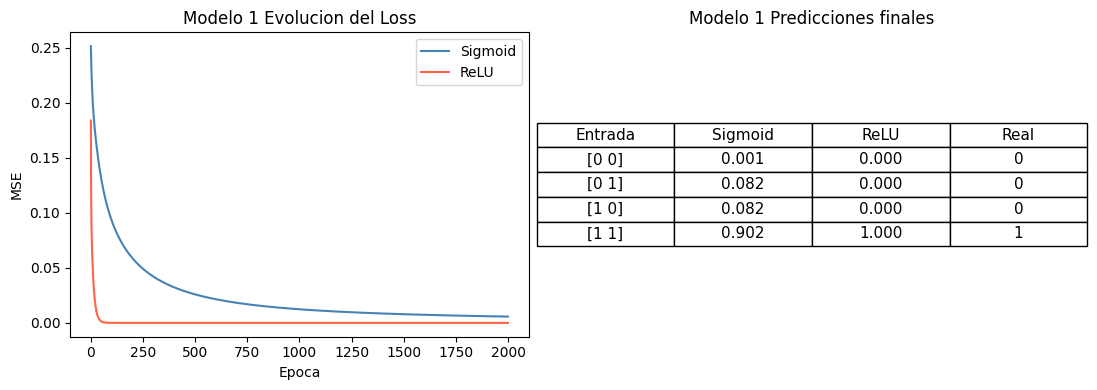

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Grafico de loss
axes[0].plot(h_sig, label='Sigmoid', color='steelblue')
axes[0].plot(h_rel, label='ReLU',    color='tomato')
axes[0].set_title('Modelo 1 Evolucion del Loss')
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('MSE'); axes[0].legend()

# Tabla de predicciones
axes[1].axis('off')
filas = []
for xi, ps, pr, yi in zip(X_and, pred_sig.flatten(), pred_rel.flatten(), y_and.flatten()):
    filas.append([str(xi.astype(int)), f'{ps:.3f}', f'{pr:.3f}', int(yi)])

tabla = axes[1].table(
    cellText=filas,
    colLabels=['Entrada', 'Sigmoid', 'ReLU', 'Real'],
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False); tabla.set_fontsize(11); tabla.scale(1.2, 1.5)
axes[1].set_title('Modelo 1 Predicciones finales')

plt.tight_layout()
plt.show()

In [12]:
acc_sig = np.mean((pred_sig >= 0.5).astype(int) == y_and) * 100
acc_rel = np.mean((pred_rel >= 0.5).astype(int) == y_and) * 100

print('Modelo 1 Perceptron simple (AND)')
print(f'  Sigmoid  |  Loss: {h_sig[-1]:.6f}  |  Accuracy: {acc_sig:.1f}%')
print(f'  ReLU     |  Loss: {h_rel[-1]:.6f}  |  Accuracy: {acc_rel:.1f}%')

Modelo 1 Perceptron simple (AND)
  Sigmoid  |  Loss: 0.005714  |  Accuracy: 100.0%
  ReLU     |  Loss: 0.000000  |  Accuracy: 100.0%


### ajuste de parametros modelo 1

Se muestran los pesos (W) y sesgo (b) **antes y despues** del entrenamiento para confirmar que backpropagation modifico los parametros.

In [13]:
print('=' * 52)
print(' ajuste de parametros perceptron simple')
print('=' * 52)

for nombre, W0, b0, Wf, bf in [
    ('Sigmoid', W0_sig, b0_sig, Wf_sig, bf_sig),
    ('ReLU',    W0_rel, b0_rel, Wf_rel, bf_rel),
]:
    print(f'\n  Activacion: {nombre}')
    print(f'  Pesos iniciales  W: {W0.flatten().round(4)}')
    print(f'  Pesos finales    W: {Wf.flatten().round(4)}')
    print(f'  Cambio neto en W:  {(Wf - W0).flatten().round(4)}')
    print(f'  Sesgo inicial    b: {b0.flatten().round(4)}')
    print(f'  Sesgo final      b: {bf.flatten().round(4)}')
    print(f'  Cambio neto en b:  {(bf - b0).flatten().round(4)}')

 ajuste de parametros perceptron simple

  Activacion: Sigmoid
  Pesos iniciales  W: [ 0.2484 -0.0691]
  Pesos finales    W: [4.6453 4.6453]
  Cambio neto en W:  [4.3969 4.7144]
  Sesgo inicial    b: [0.]
  Sesgo final      b: [-7.0653]
  Cambio neto en b:  [-7.0653]

  Activacion: ReLU
  Pesos iniciales  W: [ 0.2484 -0.0691]
  Pesos finales    W: [1. 1.]
  Cambio neto en W:  [0.7516 1.0691]
  Sesgo inicial    b: [0.]
  Sesgo final      b: [-1.]
  Cambio neto en b:  [-1.]


---
## MODELO 2 Red Neuronal con 1 Capa Oculta

*   2 entradas 4 neuronas ocultas y 1 salida  
*   Clasificación binaria XOR,
*   backpropagation: regla de la cadena en 2 capas  
*   Comparación con activación en capa oculta Sigmoid vs ReLU

In [14]:
# Dataset: compuerta logica XOR
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]],         dtype=float)

print('Dataset XOR:')
for xi, yi in zip(X_xor, y_xor):
    print(f'  {xi.astype(int)} -> {int(yi[0])}')

Dataset XOR:
  [0 0] -> 0
  [0 1] -> 1
  [1 0] -> 1
  [1 1] -> 0


In [15]:
def red_1_oculta(X, y, activacion='sigmoid', lr=0.5, epocas=3000):
    """
    Red neuronal: 2 -> 4 -> 1.
    backpropagation con regla de la cadena en 2 capas.
    devuelve pesos iniciales y finales de capa 1 para evidenciar el ajuste.
    """
    act, d_act = get_act(activacion)
    np.random.seed(42)

    W1 = np.random.randn(2, 4) * 0.5
    b1 = np.zeros((1, 4))
    W2 = np.random.randn(4, 1) * 0.5
    b2 = np.zeros((1, 1))

    # Guardar pesos antes del entrenamiento
    W1_i = W1.copy(); b1_i = b1.copy()

    historial = []

    for epoca in range(epocas):
        Z1 = X @ W1 + b1        # capa oculta pre activacion
        A1 = act(Z1)            # activación oculta
        Z2 = A1 @ W2 + b2       # capa salida pre activacion
        A2 = sigmoid(Z2)        # salida siempre sigmoid


        loss = np.mean((y - A2) ** 2)
        historial.append(loss)

        # Backpropagation
        dA2 = -2 * (y - A2) / len(y)
        dZ2 = dA2 * sigmoid_d(Z2)
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * d_act(Z1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        #Actualizacion de parametros
        W2 -= lr * dW2;  b2 -= lr * db2
        W1 -= lr * dW1;  b1 -= lr * db1

    return historial, A2, W1_i, b1_i, W1, b1

h2_sig, p2_sig, W1_0s, b1_0s, W1_fs, b1_fs = red_1_oculta(X_xor, y_xor, 'sigmoid')
h2_rel, p2_rel, W1_0r, b1_0r, W1_fr, b1_fr = red_1_oculta(X_xor, y_xor, 'relu')

print(f'Loss final  Sigmoid: {h2_sig[-1]:.6f}')
print(f'Loss final  ReLU:   {h2_rel[-1]:.6f}')

Loss final  Sigmoid: 0.022809
Loss final  ReLU:   0.166706


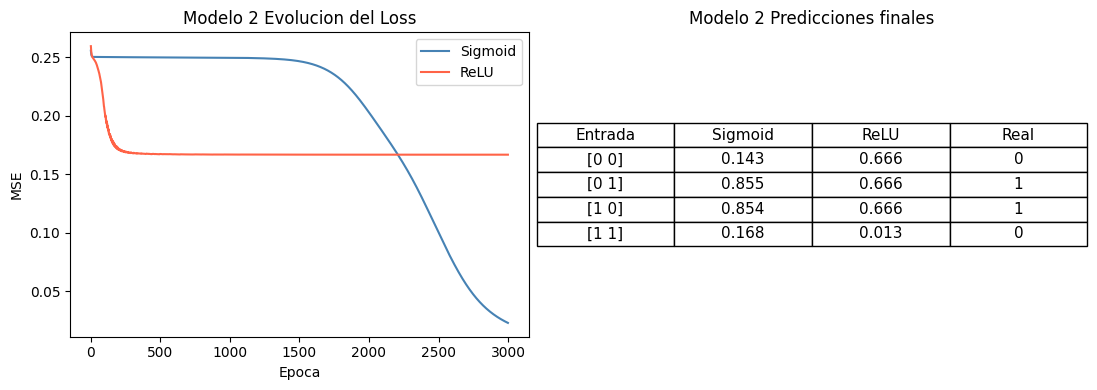

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(h2_sig, label='Sigmoid', color='steelblue')
axes[0].plot(h2_rel, label='ReLU',    color='tomato')
axes[0].set_title('Modelo 2 Evolucion del Loss')
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('MSE'); axes[0].legend()

axes[1].axis('off')
filas = []
for xi, ps, pr, yi in zip(X_xor, p2_sig.flatten(), p2_rel.flatten(), y_xor.flatten()):
    filas.append([str(xi.astype(int)), f'{ps:.3f}', f'{pr:.3f}', int(yi)])

tabla = axes[1].table(
    cellText=filas,
    colLabels=['Entrada', 'Sigmoid', 'ReLU', 'Real'],
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False); tabla.set_fontsize(11); tabla.scale(1.2, 1.5)
axes[1].set_title('Modelo 2 Predicciones finales')

plt.tight_layout()
plt.show()

In [17]:
acc2_sig = np.mean((p2_sig >= 0.5).astype(int) == y_xor) * 100
acc2_rel = np.mean((p2_rel >= 0.5).astype(int) == y_xor) * 100

print('Modelo 2 Red 1 Capa Oculta (XOR)')
print(f'  Sigmoid  |  Loss: {h2_sig[-1]:.6f}  |  Accuracy: {acc2_sig:.1f}%')
print(f'  ReLU     |  Loss: {h2_rel[-1]:.6f}  |  Accuracy: {acc2_rel:.1f}%')

Modelo 2 Red 1 Capa Oculta (XOR)
  Sigmoid  |  Loss: 0.022809  |  Accuracy: 100.0%
  ReLU     |  Loss: 0.166706  |  Accuracy: 75.0%


### Evidencia de ajuste de parámetros — Modelo 2

Se muestran los primeros 2 pesos de la capa oculta antes y después del entrenamiento.

In [18]:
print('=' * 52)
print(' Ajuste de parametros Red 1 Capa Oculta (W1)')
print('=' * 52)

for nombre, W0, b0, Wf, bf in [
    ('Sigmoid', W1_0s, b1_0s, W1_fs, b1_fs),
    ('ReLU',    W1_0r, b1_0r, W1_fr, b1_fr),
]:
    print(f'\n  Activacion: {nombre}')
    print(f'  W1 inicial (fila 0): {W0[0].round(4)}')
    print(f'  W1 final   (fila 0): {Wf[0].round(4)}')
    print(f'  Cambio neto W1[0]:   {(Wf[0] - W0[0]).round(4)}')
    print(f'  b1 inicial: {b0.flatten().round(4)}')
    print(f'  b1 final:   {bf.flatten().round(4)}')

 Ajuste de parametros Red 1 Capa Oculta (W1)

  Activacion: Sigmoid
  W1 inicial (fila 0): [ 0.2484 -0.0691  0.3238  0.7615]
  W1 final   (fila 0): [ 2.03   -0.1083  1.6467  5.3409]
  Cambio neto W1[0]:   [ 1.7817 -0.0392  1.3229  4.5794]
  b1 inicial: [0. 0. 0. 0.]
  b1 final:   [-2.5175 -0.0124 -2.8357 -2.0242]

  Activacion: ReLU
  W1 inicial (fila 0): [ 0.2484 -0.0691  0.3238  0.7615]
  W1 final   (fila 0): [ 0.5021 -0.0691  1.2254  1.245 ]
  Cambio neto W1[0]:   [0.2537 0.     0.9015 0.4834]
  b1 inicial: [0. 0. 0. 0.]
  b1 final:   [-0.5124  0.     -1.2697 -1.2844]


---
## MODELO 3 Red Multicapa (2 Capas Ocultas)




*   2 entradas → 8 neuronas → 4 neuronas → 1 salida  
*   Clasificación binaria XOR, propagacion del gradiente a traves de N capas    
*   activacion en ambas capas ocultas Sigmoid vs ReLU

In [19]:
def red_multicapa(X, y, activacion='sigmoid', lr=0.3, epocas=5000):
    """
    Red multicapa: 2 -> 8 -> 4 -> 1.
    Backpropagation generalizado a través de 3 capas.
    Las dos capas ocultas usan la activación elegida.
    La capa de salida usa Sigmoid.
    Devuelve pesos iniciales y finales de capa 1 para evidenciar el ajuste.
    """
    act, d_act = get_act(activacion)
    np.random.seed(42)

    W1 = np.random.randn(2, 8) * 0.5
    b1 = np.zeros((1, 8))
    W2 = np.random.randn(8, 4) * 0.5
    b2 = np.zeros((1, 4))
    W3 = np.random.randn(4, 1) * 0.5
    b3 = np.zeros((1, 1))

    # Guardar pesos antes del entrenamiento
    W1_i = W1.copy(); b1_i = b1.copy()

    historial = []

    for epoca in range(epocas):
        Z1 = X @ W1 + b1
        A1 = act(Z1)
        Z2 = A1 @ W2 + b2
        A2 = act(Z2)
        Z3 = A2 @ W3 + b3
        A3 = sigmoid(Z3)


        loss = np.mean((y - A3) ** 2)
        historial.append(loss)

        # Backpropagation hacia atras
        dA3 = -2 * (y - A3) / len(y)
        dZ3 = dA3 * sigmoid_d(Z3)
        dW3 = A2.T @ dZ3
        db3 = np.sum(dZ3, axis=0, keepdims=True)

        dA2 = dZ3 @ W3.T
        dZ2 = dA2 * d_act(Z2)
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * d_act(Z1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Actualizacion de parametros
        W3 -= lr * dW3;  b3 -= lr * db3
        W2 -= lr * dW2;  b2 -= lr * db2
        W1 -= lr * dW1;  b1 -= lr * db1

    return historial, A3, W1_i, b1_i, W1, b1

h3_sig, p3_sig, W3_0s, b3_0s, W3_fs, b3_fs = red_multicapa(X_xor, y_xor, 'sigmoid')
h3_rel, p3_rel, W3_0r, b3_0r, W3_fr, b3_fr = red_multicapa(X_xor, y_xor, 'relu')

print(f'Loss final  Sigmoid: {h3_sig[-1]:.6f}')
print(f'Loss final  ReLU:   {h3_rel[-1]:.6f}')

Loss final  Sigmoid: 0.227764
Loss final  ReLU:   0.000228


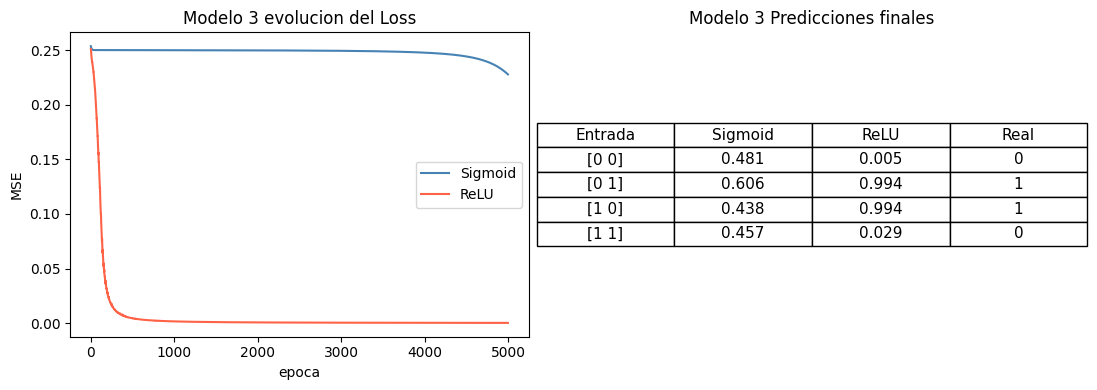

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(h3_sig, label='Sigmoid', color='steelblue')
axes[0].plot(h3_rel, label='ReLU',    color='tomato')
axes[0].set_title('Modelo 3 evolucion del Loss')
axes[0].set_xlabel('epoca'); axes[0].set_ylabel('MSE'); axes[0].legend()

axes[1].axis('off')
filas = []
for xi, ps, pr, yi in zip(X_xor, p3_sig.flatten(), p3_rel.flatten(), y_xor.flatten()):
    filas.append([str(xi.astype(int)), f'{ps:.3f}', f'{pr:.3f}', int(yi)])

tabla = axes[1].table(
    cellText=filas,
    colLabels=['Entrada', 'Sigmoid', 'ReLU', 'Real'],
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False); tabla.set_fontsize(11); tabla.scale(1.2, 1.5)
axes[1].set_title('Modelo 3 Predicciones finales')

plt.tight_layout()
plt.show()

In [21]:
acc3_sig = np.mean((p3_sig >= 0.5).astype(int) == y_xor) * 100
acc3_rel = np.mean((p3_rel >= 0.5).astype(int) == y_xor) * 100

print('MODELO 3 Red Multicapa 2 Capas Ocultas (XOR)')
print(f'  Sigmoid  |  Loss: {h3_sig[-1]:.6f}  |  Accuracy: {acc3_sig:.1f}%')
print(f'  ReLU     |  Loss: {h3_rel[-1]:.6f}  |  Accuracy: {acc3_rel:.1f}%')

MODELO 3 Red Multicapa 2 Capas Ocultas (XOR)
  Sigmoid  |  Loss: 0.227764  |  Accuracy: 75.0%
  ReLU     |  Loss: 0.000228  |  Accuracy: 100.0%


### Evidencia de ajuste de parametros Modelo 3

Se muestran los primeros pesos de la capa oculta 1 antes y despues del entrenamiento

In [22]:
print('=' * 52)
print(' Ajusto de parametros Red Multicapa (W1)')
print('=' * 52)

for nombre, W0, b0, Wf, bf in [
    ('Sigmoid', W3_0s, b3_0s, W3_fs, b3_fs),
    ('ReLU',    W3_0r, b3_0r, W3_fr, b3_fr),
]:
    print(f'\n  Activacion: {nombre}')
    print(f'  W1 inicial (fila 0): {W0[0].round(4)}')
    print(f'  W1 final   (fila 0): {Wf[0].round(4)}')
    print(f'  Cambio neto W1[0]:   {(Wf[0] - W0[0]).round(4)}')
    print(f'  b1 inicial: {b0.flatten()[:4].round(4)}')
    print(f'  b1 final:   {bf.flatten()[:4].round(4)}')

 Ajusto de parametros Red Multicapa (W1)

  Activacion: Sigmoid
  W1 inicial (fila 0): [ 0.2484 -0.0691  0.3238  0.7615 -0.1171 -0.1171  0.7896  0.3837]
  W1 final   (fila 0): [ 0.7835 -0.1529  0.9752  1.444  -0.639   0.843   1.2423  0.6062]
  Cambio neto W1[0]:   [ 0.5352 -0.0837  0.6513  0.6825 -0.5219  0.96    0.4527  0.2225]
  b1 inicial: [0. 0. 0. 0.]
  b1 final:   [ 0.0876 -0.0163  0.1416  0.2836]

  Activacion: ReLU
  W1 inicial (fila 0): [ 0.2484 -0.0691  0.3238  0.7615 -0.1171 -0.1171  0.7896  0.3837]
  W1 final   (fila 0): [ 0.3998 -0.3793  0.7325  1.5453 -0.1102 -0.1171  0.8985  1.2291]
  Cambio neto W1[0]:   [ 0.1514 -0.3102  0.4087  0.7838  0.0069  0.      0.1089  0.8453]
  b1 inicial: [0. 0. 0. 0.]
  b1 final:   [0.3687 0.3793 0.2633 0.2243]


---
## Comparación global de los tres modelos

In [23]:
# Tabla resumen
resumen = pd.DataFrame({
    'Modelo':        ['Perceptron', 'Perceptron', '1 Capa Oculta', '1 Capa Oculta', 'Multicapa', 'Multicapa'],
    'Activación':    ['Sigmoid', 'ReLU', 'Sigmoid', 'ReLU', 'Sigmoid', 'ReLU'],
    'Loss final':    [
        round(h_sig[-1],6), round(h_rel[-1],6),
        round(h2_sig[-1],6), round(h2_rel[-1],6),
        round(h3_sig[-1],6), round(h3_rel[-1],6)
    ],
    'Accuracy (%)':  [
        round(acc_sig,1), round(acc_rel,1),
        round(acc2_sig,1), round(acc2_rel,1),
        round(acc3_sig,1), round(acc3_rel,1)
    ]
})
print(resumen.to_string(index=False))

       Modelo Activación  Loss final  Accuracy (%)
   Perceptron    Sigmoid    0.005714         100.0
   Perceptron       ReLU    0.000000         100.0
1 Capa Oculta    Sigmoid    0.022809         100.0
1 Capa Oculta       ReLU    0.166706          75.0
    Multicapa    Sigmoid    0.227764          75.0
    Multicapa       ReLU    0.000228         100.0


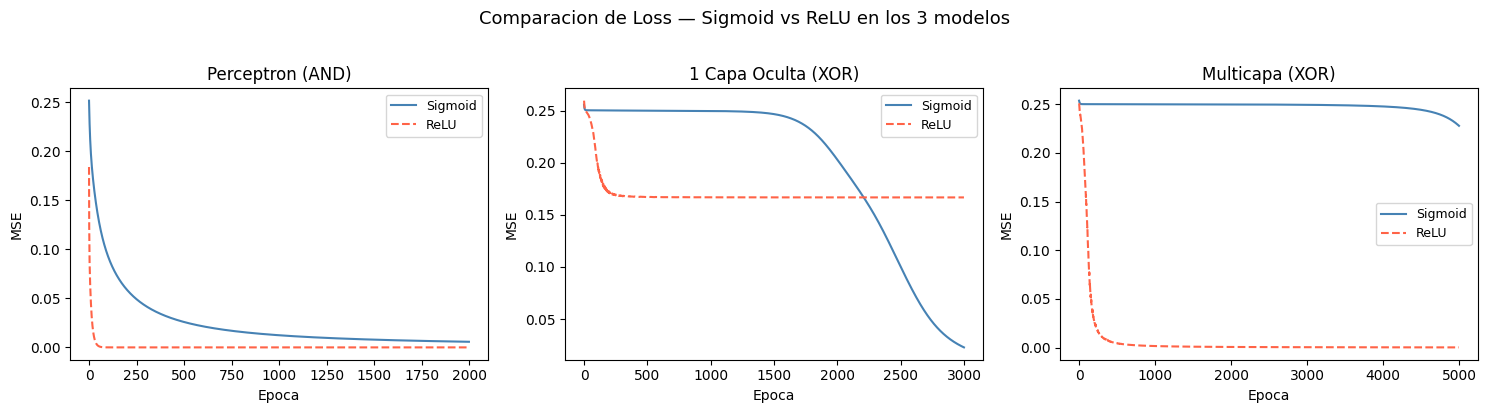

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

datos = [
    ('Perceptron (AND)', h_sig,  h_rel),
    ('1 Capa Oculta (XOR)', h2_sig, h2_rel),
    ('Multicapa (XOR)',  h3_sig, h3_rel),
]

for ax, (titulo, hs, hr) in zip(axes, datos):
    ax.plot(hs, label='Sigmoid', color='steelblue')
    ax.plot(hr, label='ReLU',    color='tomato', linestyle='--')
    ax.set_title(titulo)
    ax.set_xlabel('Epoca')
    ax.set_ylabel('MSE')
    ax.legend(fontsize=9)

plt.suptitle('Comparacion de Loss — Sigmoid vs ReLU en los 3 modelos', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Análisis y Conclusiones

### Diferencias entre los tres modelos



*   perceptrón simple (sin capa oculta) solo puede resolver problemas linealmente separables como AND, para XOR un problema no lineal es insuficiente ya que ningun conjunto de pesos puede separar correctamente las clases.


*   La red con 1 capa oculta introduce capacidad no lineal gracias a la capa intermedia, por lo cual esto le permite aprender XOR, el backpropagation requiere propagar una capa mas hacia atras usando la regla de la cadena.


*   La red multicapa (2 capas ocultas) tiene mayor capacidad ya que puede aprender funciones más complejas y con mayor precisión.

---

### Efecto de las funciones de activación



*  Sigmoid produce gradientes mas acotados lo que genera una curva de descenso estable y predecible, su posible desventaja es la saturación, cuando los valores son muy grandes o pequeños, la derivada se acerca a cero y los gradientes se desvanecen.


*   ReLU no satura en la región positiva lo que permite gradientes mas grandes en las primeras etapas, en el perceptrón esto se nota ya que ReLU puede ser menos estable dado que opera sobre una sola neurona sin capa.

---

### Hallazgos y dificulades

* La arquitectura importa más que la función de activación para determinar qué
problemas puede resolver un modelo.

* ReLU no convergía de forma estable en algunos intentos al cambiar la semilla, porque algunas neuronas recibían valores negativos desde el inicio y sus gradientes eran 0 desde la primera epoca


*   El perceptron simple no puede resolver XOR al intentar usarlo con ese dataset los resultados eran incorrectos independientemente del número de epocas, lo que llevo a la necesidad de una capa oculta.

